**ANÁLISE EXPLORATÓRIA DE DADOS**  
OBJETIVO: 


In [128]:
# Instalando as bibliotecas necessárias
!pip install pandas
!pip install matplotlib
!pip install seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Program Files\Python311\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Program Files\Python311\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Program Files\Python311\python.exe -m pip install --upgrade pip


Calcular medidas estatísticas básicas, como:  
Média;  
Mediana;  
Valor mínimo;  
Valor máximo;  
Criar pelo menos um gráfico, podendo ser:  
Histograma; ou Boxplot;


In [129]:
# Importando as bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [130]:
# Importando o arquivo CSV (ler e concatenar vários arquivos)
files = ['CSV_01.csv', 'CSV_02.csv']
dfsalario = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)

In [131]:
# Visualizando as primeiras linhas do DataFrame
dfsalario.head()

,DEPARTAMENTO,CARGO,SALARIO,CONTINENTE,PAÍS,ESTADO,CIDADE
0,Accounting,Accounting Manager,12008,NaN,NaN,NaN,NaN
1,Accounting,Public Accountant,8300,NaN,NaN,NaN,NaN
2,Administration,Administration Assistant,4400,NaN,NaN,NaN,NaN
3,Executive,President,24000,NaN,NaN,NaN,NaN
4,Executive,Administration Vice President,17000,NaN,NaN,NaN,NaN


In [132]:
# Visualizando os tipos de dados das colunas
dfsalario.dtypes

DEPARTAMENTO      str
CARGO             str
SALARIO         int64
CONTINENTE        str
PAÍS              str
ESTADO            str
CIDADE            str
dtype: object

In [133]:
# Visualizando estatísticas descritivas do DataFrame
dfsalario.describe().astype(int)

,SALARIO
count,179
mean,6659
std,3939
min,2100
25%,3150
50%,6400
75%,9000
max,24000


In [134]:
# Visualizando o valor médio da coluna "Salario" por departamento e cargo
dfsalario.groupby(['DEPARTAMENTO', 'CARGO'])['SALARIO'].mean().astype(int).reset_index()

,DEPARTAMENTO,CARGO,SALARIO
0,Accounting,Accounting Manager,12008
1,Accounting,Public Accountant,8300
2,Administration,Administration Assistant,4400
3,Executive,Administration Vice President,17000
4,Executive,President,24000
5,Finance,Accountant,7920
6,Finance,Finance Manager,12008
7,Human Resources,Human Resources Representative,6500
8,IT,Programmer,5760
9,Marketing,Marketing Manager,13000


In [135]:
# Visualizando o valor mediana da coluna "Salario" por departamento e cargo
dfsalario.groupby(['DEPARTAMENTO', 'CARGO'])['SALARIO'].median().astype(int).reset_index()

,DEPARTAMENTO,CARGO,SALARIO
0,Accounting,Accounting Manager,12008
1,Accounting,Public Accountant,8300
2,Administration,Administration Assistant,4400
3,Executive,Administration Vice President,17000
4,Executive,President,24000
5,Finance,Accountant,7800
6,Finance,Finance Manager,12008
7,Human Resources,Human Resources Representative,6500
8,IT,Programmer,4800
9,Marketing,Marketing Manager,13000


In [136]:
# Visualizando o valor minimo da coluna "Salario" por departamento e cargo
dfsalario.groupby(['DEPARTAMENTO', 'CARGO'])['SALARIO'].min().reset_index()

,DEPARTAMENTO,CARGO,SALARIO
0,Accounting,Accounting Manager,12008
1,Accounting,Public Accountant,8300
2,Administration,Administration Assistant,4400
3,Executive,Administration Vice President,17000
4,Executive,President,24000
5,Finance,Accountant,6900
6,Finance,Finance Manager,12008
7,Human Resources,Human Resources Representative,6500
8,IT,Programmer,4200
9,Marketing,Marketing Manager,13000


In [137]:
# Visualizando o valor máximo da coluna "Salario" por departamento e cargo.
dfsalario.groupby(['DEPARTAMENTO','CARGO'])['SALARIO'].max().reset_index()

,DEPARTAMENTO,CARGO,SALARIO
0,Accounting,Accounting Manager,12008
1,Accounting,Public Accountant,8300
2,Administration,Administration Assistant,4400
3,Executive,Administration Vice President,17000
4,Executive,President,24000
5,Finance,Accountant,9000
6,Finance,Finance Manager,12008
7,Human Resources,Human Resources Representative,6500
8,IT,Programmer,9000
9,Marketing,Marketing Manager,13000


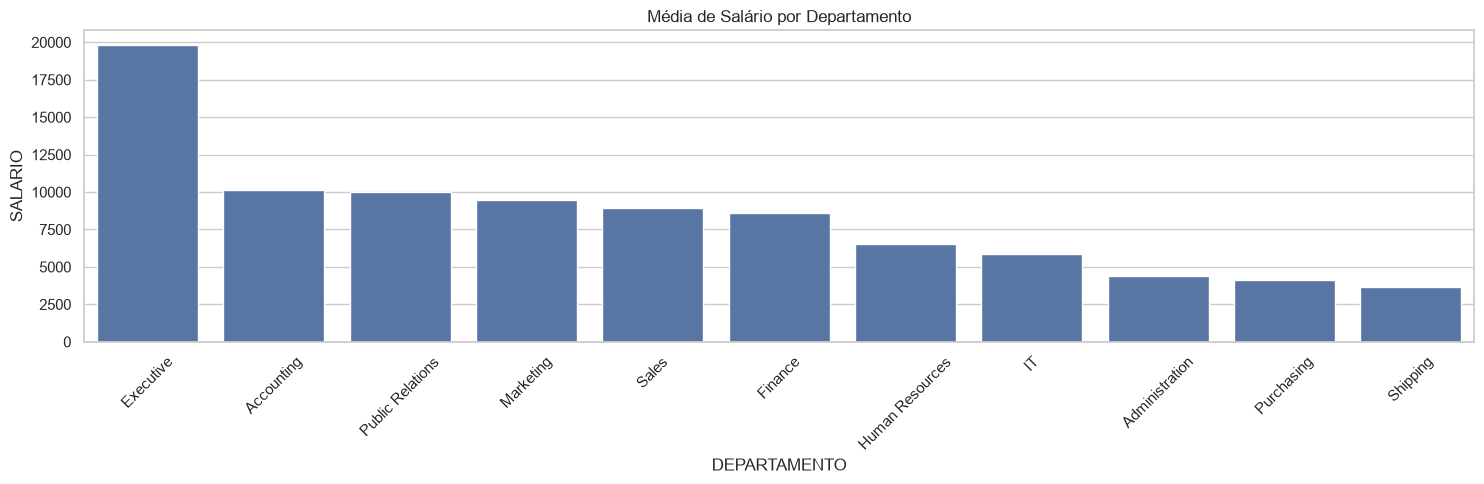

In [138]:
# Visualizando a media de salario por departamento em um gráfico de barras.
ordem_departamentos = dfsalario.groupby('DEPARTAMENTO')['SALARIO'].mean().sort_values(ascending=False).index
plt.figure(figsize=(15, 5))
sns.barplot(
    data=dfsalario.sort_values('SALARIO', ascending=False),
    x='DEPARTAMENTO',
    y='SALARIO',
    order=ordem_departamentos,
    errorbar=None,
)
plt.xlabel('DEPARTAMENTO')
plt.ylabel('SALARIO')
plt.title('Média de Salário por Departamento')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

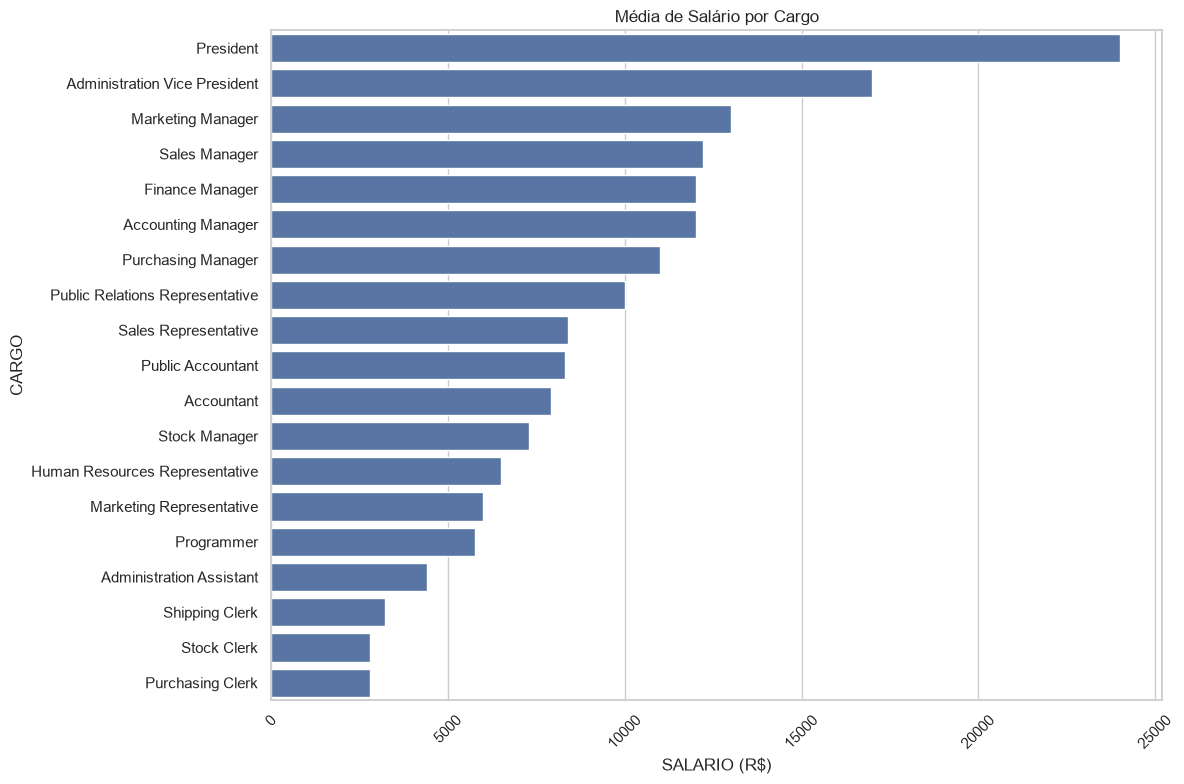

In [139]:
# Visualizando a media de salario por cargo em um gráfico de barras.
ordem_cargos = dfsalario.groupby('CARGO')['SALARIO'].mean().sort_values(ascending=False).index
plt.figure(figsize=(12, 8))
sns.barplot(
    data=dfsalario.sort_values('SALARIO', ascending=False),
    x='SALARIO',
    y='CARGO',
    order=ordem_cargos,
    errorbar=None,
)
plt.xlabel('SALARIO (R$)')
plt.ylabel('CARGO')
plt.title('Média de Salário por Cargo')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

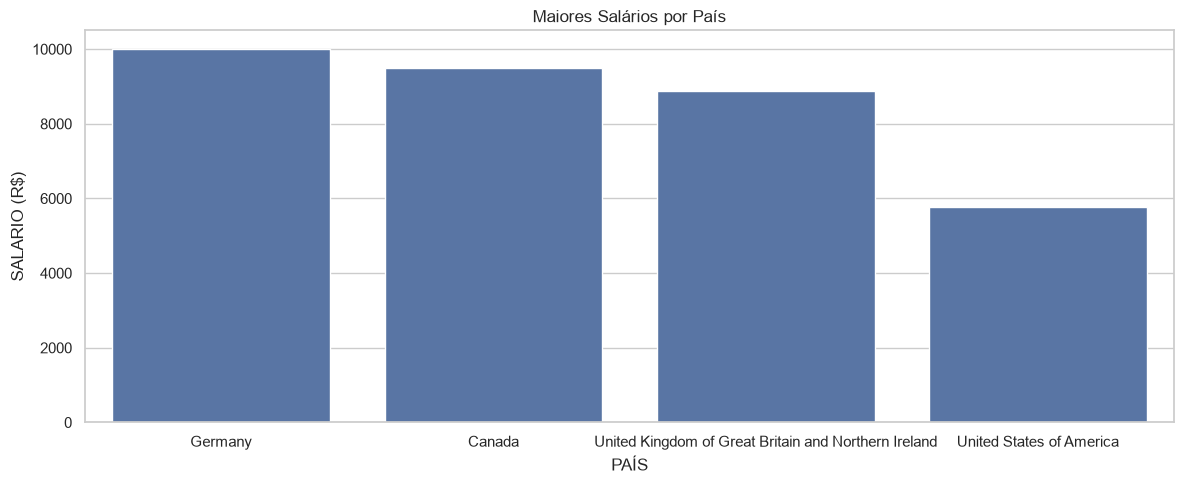

In [140]:
# Gráfico de salários por País.
ordem_paises = dfsalario.groupby('PAÍS')['SALARIO'].mean().sort_values(ascending=False).index
plt.figure(figsize=(12, 5))
sns.barplot(
    data=dfsalario,
    x='PAÍS',
    y='SALARIO',
    order=ordem_paises,
    errorbar=None
)
plt.xlabel('PAÍS')
plt.ylabel('SALARIO (R$)')
plt.title('Maiores Salários por País')
plt.tight_layout()
plt.show()

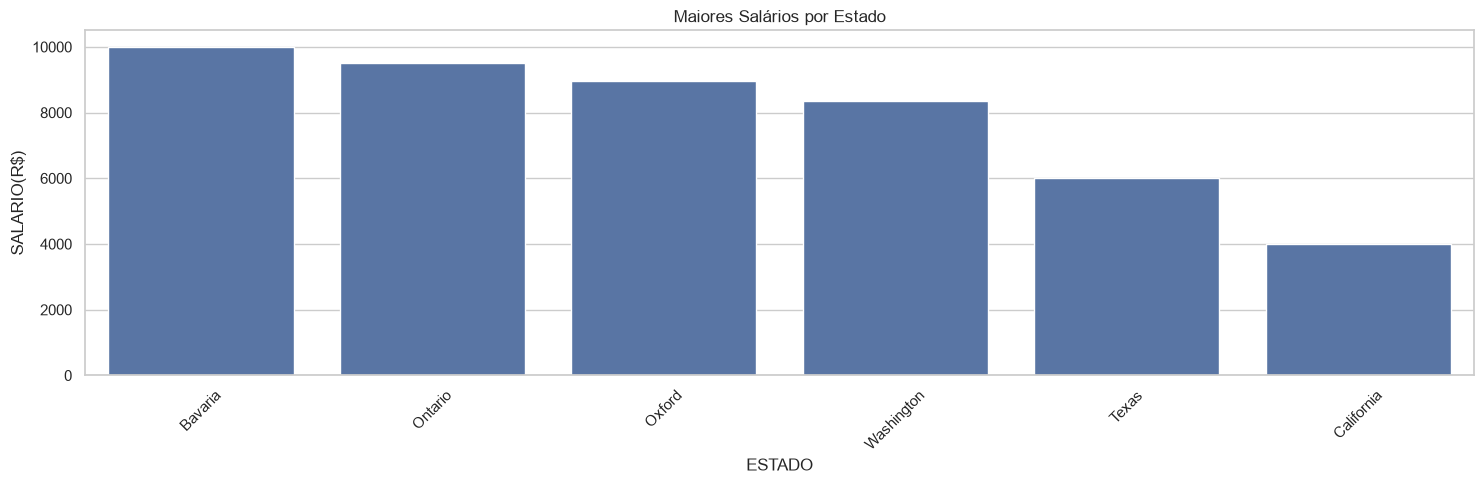

In [141]:
# Gráfico de salários por Estado.
ordem_estados = dfsalario.groupby('ESTADO')['SALARIO'].mean().sort_values(ascending=False).index
plt.figure(figsize=(15, 5))
sns.barplot(
    data=dfsalario,
    x='ESTADO',
    y='SALARIO',
    order=ordem_estados,
    errorbar=None
)
plt.xlabel('ESTADO')
plt.ylabel('SALARIO(R$)')
plt.title('Maiores Salários por Estado')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

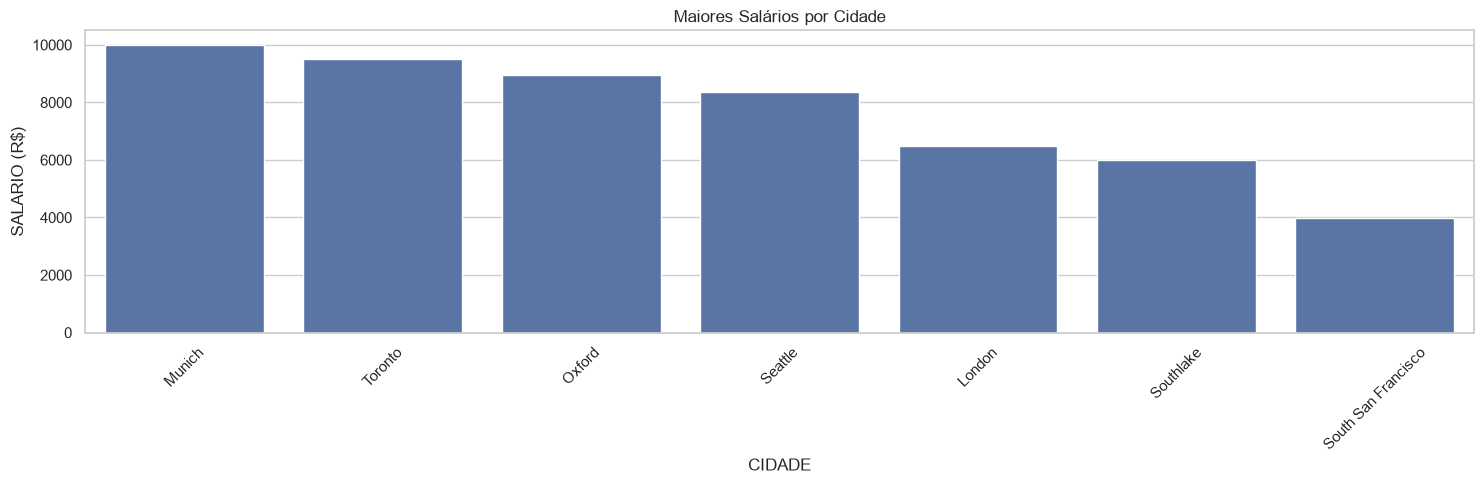

In [142]:
# Gráfico de salários por cidade.
ordem_cidades = dfsalario.groupby('CIDADE')['SALARIO'].mean().sort_values(ascending=False).index
plt.figure(figsize=(15, 5))
sns.barplot(
    data=dfsalario,
    x='CIDADE',
    y='SALARIO',
    order=ordem_cidades,
    errorbar=None
)
plt.xlabel('CIDADE')
plt.ylabel('SALARIO (R$)')
plt.title('Maiores Salários por Cidade')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Gerando os gráficos:
1. Gráfico de barras exibindo a média de salário por departamento e cargo

2. Gráfico em boxplots para encontrar os desvios de salários em relação a media de salário e possíveis Outliers.

<Axes: xlabel='DEPARTAMENTO', ylabel='SALARIO'>

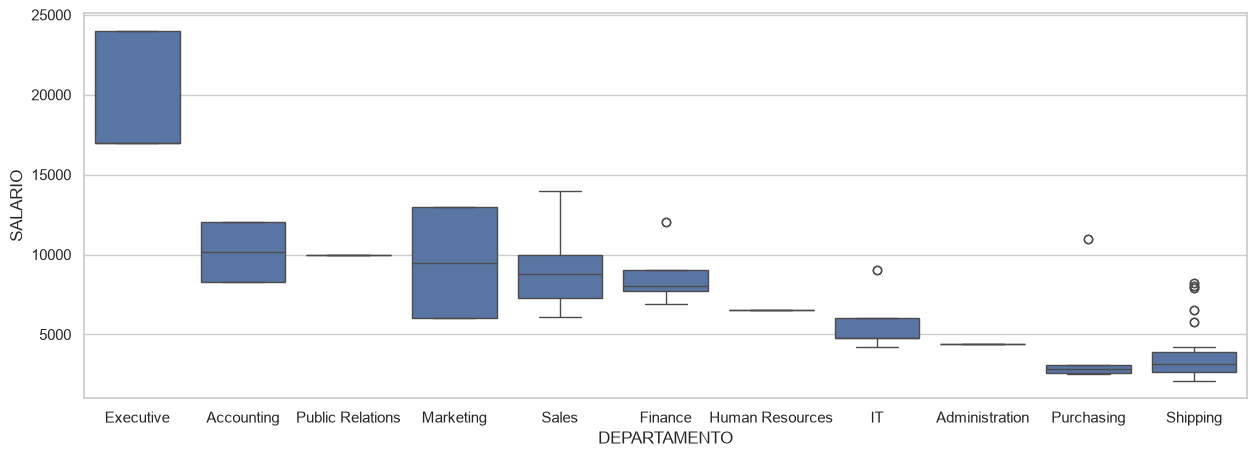

In [143]:
# Visualizar um boxplot do salário por departamento e cargo.
dfsalario['SALARIO'] = pd.to_numeric(dfsalario['SALARIO'], errors='coerce')
ordem_salario = dfsalario.groupby('DEPARTAMENTO')['SALARIO'].mean().sort_values(ascending=False).index
plt.figure(figsize=(15, 5))
sns.boxplot(
data=dfsalario, 
x='DEPARTAMENTO', 
y='SALARIO',
order=ordem_salario
)

Análise dos gráficos:
1. A maior média salárial são do departamento Executive.
2. A menor média salarial pertence ao departemento Shipping.
2. Os departamentos que apresentam os menores desvios de média salarial são: Administration, Human Resources e Public Relations.
3. O departamento Shipping possui mais Outliers de dasos salarial.
